In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def FITGridEven(self, x_len, y_len, z_len, nx, ny, nz):
    # Function runs automatically to create a 3D grid

    # nx, ny, nz - Number of cells in X, Y and Z directions
    # x_len, y_len, z_len - Cells lengths in X, Y and Z directions

    self.nx = nx
    self.ny = ny
    self.nz = nz
    
    # ------ PRIMARY GRID G -------
    # Evenly spaced nodes (to get nx, we need nx+1 because of Python numbering)
    # Primary grid G
    self.x_G = np.linspace(0, x_len, nx)
    self.y_G = np.linspace(0, y_len, ny)
    self.z_G = np.linspace(0, z_len, nz)

    # Calculate the difference between the primary nodes
    self.dx = np.diff(self.x_G)
    self.dy = np.diff(self.y_G)
    self.dz = np.diff(self.z_G)
    
    # Create arrays of mesh lengths
    # Meshgrid creates 3D blocks where every cell knows its own dimensions
    DX_G, DY_G, DZ_G = np.meshgrid(self.dx, self.dy, self.dz, indexing='ij')

    # Areas of the faces on grid G
    self.area_x_G = DY_G * DZ_G
    self.area_y_G = DX_G * DZ_G
    self.area_z_G = DX_G * DY_G

    # Volume of one cell
    self.volume_G = DX_G * DY_G * DZ_G
    

    # ------ DUAL GRID G_HAT -------
    # Create the dual grid nodes by staggering (do not include the last node)
    # Dual grid G_hat
    # self.x_G_hat = self.x_G[:-1] + (self.dx / 2)
    # self.y_G_hat = self.y_G[:-1] + (self.dy / 2)
    # self.z_G_hat = self.z_G[:-1] + (self.dz / 2)

    # # Calculate the difference between the primary nodes
    # self.dx_hat = self.dx.copy()
    # self.dy_hat = self.dy.copy()
    # self.dz_hat = self.dz.copy()

    shift_x = self.dx[0] / 2.0
    shift_y = self.dy[0] / 2.0
    shift_z = self.dz[0] / 2.0

    self.x_G_hat = self.x_G + shift_x   # last entry will be outside domain
    self.y_G_hat = self.y_G + shift_y
    self.z_G_hat = self.z_G + shift_z

    self.dx_hat = self.dx.copy()
    self.dy_hat = self.dy.copy()
    self.dz_hat = self.dz.copy()

    # Create arrays of mesh lengths
    # Meshgrid creates 3D blocks where every cell knows its own dimensions
    DX_G_hat, DY_G_hat, DZ_G_hat = np.meshgrid(self.dx_hat, self.dy_hat, self.dz_hat, indexing='ij')

    # Areas of the faceson grid G_hat
    self.area_x_G_hat = DY_G_hat * DZ_G_hat
    self.area_y_G_hat = DX_G_hat * DZ_G_hat
    self.area_z_G_hat = DX_G_hat * DY_G_hat

    # Volume of one cell
    self.volume_G_hat = DX_G_hat * DY_G_hat * DZ_G_hat

    print(f"Grid successfully created with {nx * ny * nz} total cells!")

def topological_matrices(self):
    # For creation of C and S matrices
    # Done via Kronecker method

    # First create 1D arrays of ones for each element count
    ones_x = np.ones(self.nx)
    ones_y = np.ones(self.ny)
    ones_z = np.ones(self.nz)

    # Second, create the P-matrices that will be used for 3D derivative using scipy.sparse.diags, here named sp.diags
    # [-ones_x, ones_x] to ensure that the diagonals have [-1 ,1]
    # [0, 1] to ensure that main diagonal (0) and first upper diagonal (1) is filled
    self.Px = sp.diags([-ones_x, ones_x], [0, 1], shape=(self.nx, self.nx))
    self.Py = sp.diags([-ones_y, ones_y], [0, 1], shape=(self.ny, self.ny))
    self.Pz = sp.diags([-ones_z, ones_z], [0, 1], shape=(self.nz, self.nz))

    # Convert to CSR (Compressed Sparse Row) format
    # Apparently, highly optimized for matrix multiplication later
    self.Px = self.Px.tocsr()
    self.Py = self.Py.tocsr()
    self.Pz = self.Pz.tocsr()


    # Identity matrixes
    Ix = sp.eye(self.nx)
    Iy = sp.eye(self.ny)
    Iz = sp.eye(self.nz)

    # Third, expand to 3D using scipy.sparse.kron (Kronecker product)
    # Note: Nest the kron functions because, apparently, scipy's kron only takes two arguments at a time.

    # Example: Dx = I_z kron I_y kron P_x, but Dy = I_z kron P_y kron I_x
    # Order matters!
    self.Dx = sp.kron(Iz, sp.kron(Iy, self.Px)).tocsr()
    self.Dy = sp.kron(Iz, sp.kron(self.Py, Ix)).tocsr()
    self.Dz = sp.kron(self.Pz, sp.kron(Iy, Ix)).tocsr()

    # Assemble curl matrix C
    self.C = sp.bmat([
        [None,      -self.Dz,  self.Dy],
        [self.Dz,   None,     -self.Dx],
        [-self.Dy,   self.Dx,  None]
    ], format='csr')

    # Assemble divergence matrix S
    self.S = sp.bmat([
        [self.Dx, self.Dy, self.Dz]
    ], format='csr')


    return self.C, self.S

def main():
    # Example usage of the FITGridEven class
    my_grid = FITGridEven(self, x_len=1.0, y_len=1.0, z_len=1.0, nx=3, ny=3, nz=3)
    C_matrix, S_matrix = my_grid.topological_matrices(self)

    # Verify the output
    print(f"Grid created!")
    print(f"Shapes of the matrices G and G_hat: {my_grid.x_G.shape}, {my_grid.x_G_hat.shape}")
    print(f"Shape of the C matrix: {my_grid.C.shape}")
    print(f"Shape of the S matrix: {my_grid.S.shape}")

if __name__ == "__main__":
    main()



Grid successfully created with 27 total cells!


AttributeError: 'NoneType' object has no attribute 'topological_matrices'

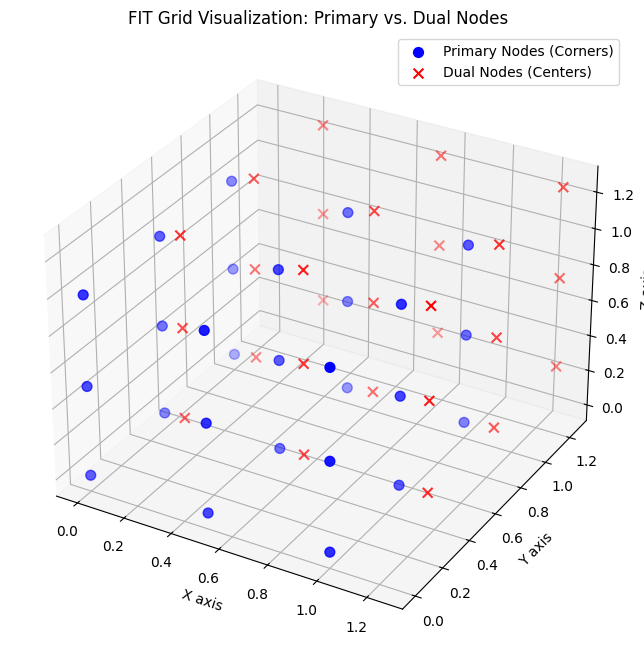

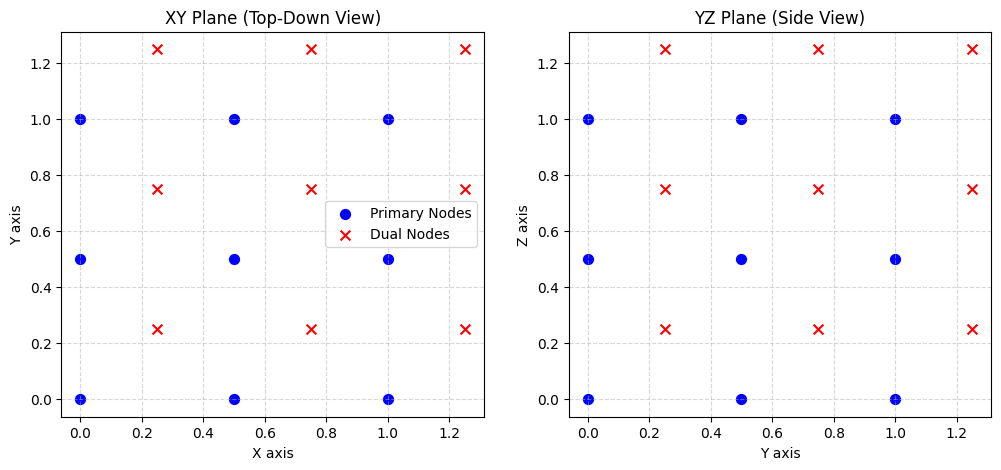

In [15]:
# 1. Generate all the 3D coordinates using meshgrid
# meshgrid takes our 1D arrays (like [0, 0.5, 1]) and turns them into 
# a full 3D coordinate system so we can plot every single point.
X_prim, Y_prim, Z_prim = np.meshgrid(my_grid.x_G, my_grid.y_G, my_grid.z_G, indexing='ij')
X_dual, Y_dual, Z_dual = np.meshgrid(my_grid.x_G_hat, my_grid.y_G_hat, my_grid.z_G_hat, indexing='ij')

# 2. Set up the 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot the points (scatter plot)
# Primary nodes in Blue ('b'), Dual nodes in Red ('r')
ax.scatter(X_prim, Y_prim, Z_prim, c='b', marker='o', s=50, label='Primary Nodes (Corners)')
ax.scatter(X_dual, Y_dual, Z_dual, c='r', marker='x', s=50, label='Dual Nodes (Centers)')

# 4. Add labels and a legend to make it look nice
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('FIT Grid Visualization: Primary vs. Dual Nodes')
ax.legend()

fig2, (ax_xy, ax_yz) = plt.subplots(1, 2, figsize=(12, 5))

# 2D Grids
# We create 2D coordinates using just the X and Y nodes
X_prim_2d, Y_prim_2d = np.meshgrid(my_grid.x_G, my_grid.y_G, indexing='ij')
X_dual_2d, Y_dual_2d = np.meshgrid(my_grid.x_G_hat, my_grid.y_G_hat, indexing='ij')

ax_xy.scatter(X_prim_2d, Y_prim_2d, c='b', marker='o', s=50, label='Primary Nodes')
ax_xy.scatter(X_dual_2d, Y_dual_2d, c='r', marker='x', s=50, label='Dual Nodes')
ax_xy.set_xlabel('X axis')
ax_xy.set_ylabel('Y axis')
ax_xy.set_title('XY Plane (Top-Down View)')
ax_xy.legend()
ax_xy.grid(True, linestyle='--', alpha=0.5) # Adds a faint background grid

# --- Plot 2: The YZ Plane (Side View) ---
# We create 2D coordinates using just the Y and Z nodes
Y_prim_yz, Z_prim_yz = np.meshgrid(my_grid.y_G, my_grid.z_G, indexing='ij')
Y_dual_yz, Z_dual_yz = np.meshgrid(my_grid.y_G_hat, my_grid.z_G_hat, indexing='ij')

ax_yz.scatter(Y_prim_yz, Z_prim_yz, c='b', marker='o', s=50)
ax_yz.scatter(Y_dual_yz, Z_dual_yz, c='r', marker='x', s=50)
ax_yz.set_xlabel('Y axis')
ax_yz.set_ylabel('Z axis')
ax_yz.set_title('YZ Plane (Side View)')
ax_yz.grid(True, linestyle='--', alpha=0.5)

# 9. Now show ALL the figures we created!
plt.show()